In [ ]:
## 1. Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
%pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 90.8 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


In [ ]:
# For quantum encoding (Pennylane or Qiskit)
import pennylane as qml

In [ ]:
## 2. Load Harmonized TNBC Dataset
import os
import pandas as pd

file_path = os.path.expanduser("/content/cbio_seer_merged_tnbc.csv")
df = pd.read_csv(file_path)
df.head()

,er_status,her2_status,grade,pr_status,tumor_size,tumor_stage,nodes_positive,chemotherapy,sex,age,...,surgery,vital_status_encoded,radiation_encoded,chemotherapy_encoded,surgery_encoded,laterality_encoded,histology_encoded,dataset_source,race,race_encoded
0,Negative,Negative,3,Negative,17.0,1,0,YES,Female,52.14,...,MASTECTOMY,1,1,1,1.0,1.0,1,cbio,NaN,NaN
1,Negative,Negative,3,Negative,17.0,1,0,YES,Female,52.14,...,MASTECTOMY,1,1,1,1.0,1.0,1,cbio,NaN,NaN
2,Negative,Negative,3,Negative,17.0,1,0,YES,Female,52.14,...,MASTECTOMY,1,1,1,1.0,1.0,1,cbio,NaN,NaN
3,Negative,Negative,3,Negative,40.0,2,4,YES,Female,50.42,...,MASTECTOMY,0,1,1,1.0,1.0,1,cbio,NaN,NaN
4,Negative,Negative,3,Negative,40.0,2,4,YES,Female,50.42,...,MASTECTOMY,0,1,1,1.0,1.0,1,cbio,NaN,NaN


In [ ]:
## 3. Select Features for Quantum Encoding
# Select features
features = ["tumor_size", "age", "nodes_positive"]
X = df[features].copy()

In [ ]:
## 4. Normalize Features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)
pd.DataFrame(X_norm, columns=features).head()

,tumor_size,age,nodes_positive
0,0.017017,0.456883,0.000000
1,0.017017,0.456883,0.000000
2,0.017017,0.456883,0.000000
3,0.040040,0.435724,0.040404
4,0.040040,0.435724,0.040404


In [ ]:
## 5. Convert Features → Rotation Angles
# Angle encoding: map normalized values to [0, π]
angles = np.pi * X_norm
angles_df = pd.DataFrame(angles, columns=[f"{f}_angle" for f in features])
angles_df.head()

,tumor_size_angle,age_angle,nodes_positive_angle
0,0.053461,1.435340,0.000000
1,0.053461,1.435340,0.000000
2,0.053461,1.435340,0.000000
3,0.125789,1.368867,0.126933
4,0.125789,1.368867,0.126933


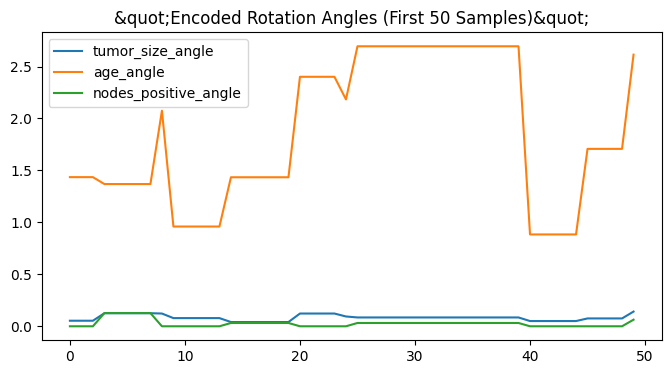

In [ ]:
## 6. Visualize Encoded Angles
plt.figure(figsize=(8,4))
plt.plot(angles_df.iloc[:50])

plt.title("&quot;Encoded Rotation Angles (First 50 Samples)&quot;")
plt.legend(angles_df.columns)
plt.show()

In [ ]:
## 7. Bloch Sphere Visualization (Optional)
# Example: visualize one feature’s angle on a Bloch sphere
from pennylane import numpy as pnp
def bloch_vector(theta):
    return np.array([np.sin(theta), 0, np.cos(theta)])

theta = angles_df["tumor_size_angle"].iloc[0]
bloch_vector(theta)

array([0.05343507, 0.        , 0.99857133])

In [ ]:
pip install qiskit matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.5 MB/s eta 0:00:00


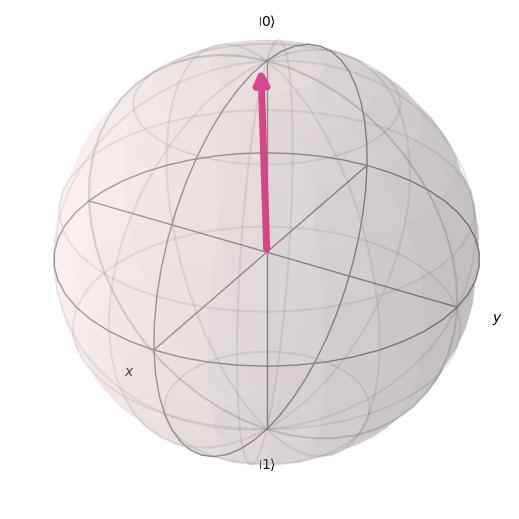

In [ ]:
from qiskit.visualization import plot_bloch_vector

# Pass your 3D array directly into Qiskit's plotter
plot_bloch_vector(bloch_vector(theta))

In [ ]:
## 8. Save Quantum-Ready Dataset
angles_df.to_csv("tnbc_quantum_ready.csv", index=False)

In [ ]:
features_v2 = ["grade", "survival_months"]

# 1. Copy features and convert all columns to numeric types
X_v2 = df[features_v2].copy()

# Force non-numeric text to NaN, then drop all NaNs
for col in features_v2:
    X_v2[col] = pd.to_numeric(X_v2[col], errors="coerce")

X_v2 = X_v2.dropna()

# 2. Normalize the clean numeric dataset
scaler_v2 = MinMaxScaler()
X_v2_norm = scaler_v2.fit_transform(X_v2)

# 3. View the normalized DataFrame
df_v2_norm = pd.DataFrame(X_v2_norm, columns=features_v2)
df_v2_norm.head()

,grade,survival_months
0,1.0,0.500000
1,1.0,0.500000
2,1.0,0.500000
3,1.0,0.092553
4,1.0,0.092553


In [ ]:
import numpy as np

angles = np.pi * X_v2_norm
angles_df = pd.DataFrame(
    angles, columns=[f"{f}_angle" for f in features_v2]
)
angles_df.head()

,grade_angle,survival_months_angle
0,3.141593,1.570796
1,3.141593,1.570796
2,3.141593,1.570796
3,3.141593,0.290762
4,3.141593,0.290762


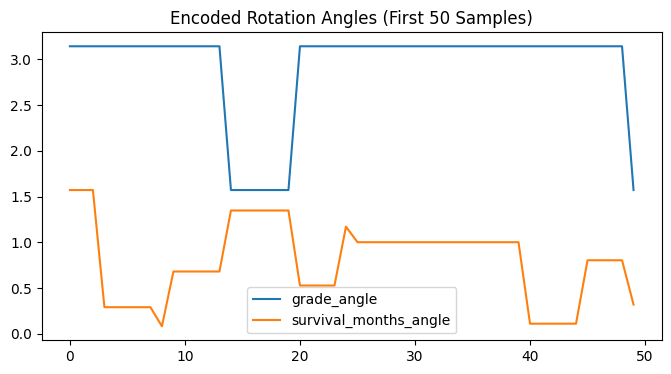

In [ ]:

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(angles_df.iloc[:50])

plt.title("Encoded Rotation Angles (First 50 Samples)")
plt.legend(angles_df.columns)
plt.show()

In [ ]:
## 7. Bloch Sphere Visualization (Optional)
# Example: visualize one feature’s angle on a Bloch sphere
from pennylane import numpy as pnp
def bloch_vector(theta):
    return np.array([np.sin(theta), 0, np.cos(theta)])

theta = angles_df["grade_angle"].iloc[0]
bloch_vector(theta)

array([ 1.2246468e-16,  0.0000000e+00, -1.0000000e+00])

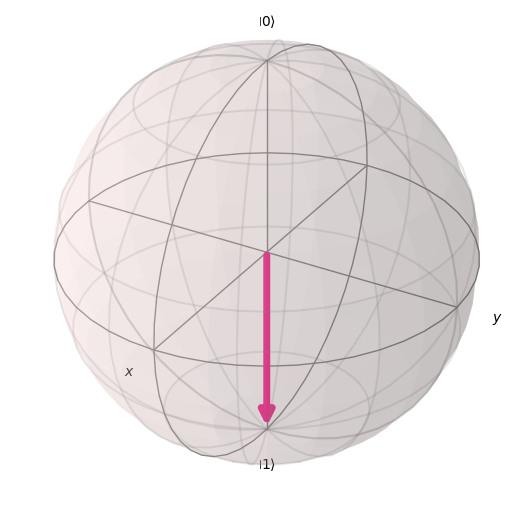

In [ ]:
from qiskit.visualization import plot_bloch_vector

# Pass your 3D array directly into Qiskit's plotter
plot_bloch_vector(bloch_vector(theta))

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# 1. Select numeric features for a SINGLE patient (Row 0)
features = ["tumor_size", "tumor_stage", "nodes_positive", "age"]
patient_0 = df[features].iloc[0].values.astype(float)  # 4 features

# 2. Pad to power of 2 (4 features -> 2 qubits)
n_qubits = int(np.ceil(np.log2(len(patient_0))))
padded = np.zeros(2**n_qubits)
padded[: len(patient_0)] = patient_0

# 3. Normalize (L2 norm)
norm = np.linalg.norm(padded)
normalized = padded / norm if norm > 0 else padded

# 4. Initialize Circuit
qc = QuantumCircuit(n_qubits)
qc.initialize(normalized, range(n_qubits))

print(f"Patient 0 statevector initialized on {n_qubits} qubits!")

Patient 0 statevector initialized on 2 qubits!
